In [2]:

import matplotlib.pyplot as plt
import numpy as np

import mne
import torch
import torch.nn as nn
import torchaudio

In [3]:
file = "../data/edf/eeg_test.edf"
raw = mne.io.read_raw_edf(file)

Extracting EDF parameters from ../data/edf/eeg_test.edf...
Setting channel info structure...
Creating raw.info structure...


In [4]:
n_time_samps = raw.n_times
time_secs = raw.times
ch_names = raw.ch_names
n_chan = len(ch_names)  # note: there is no raw.n_channels attribute
print(
    f"the (cropped) sample data object has {n_time_samps} time samples and "
    f"{n_chan} channels."
)
print(f"The last time sample is at {time_secs[-1]} seconds.")
print("The first few channel names are {}.".format(", ".join(ch_names[:3])))
print()  # insert a blank line in the output

# some examples of raw.info:
print("bad channels:", raw.info["bads"])  # chs marked "bad" during acquisition
print(raw.info["sfreq"], "Hz")  # sampling frequency
print(raw.info["description"], "\n")  # miscellaneous acquisition info

print(raw.info)

the (cropped) sample data object has 25984 time samples and 58 channels.
The last time sample is at 202.9921875 seconds.
The first few channel names are TIME_STAMP_s, TIME_STAMP_ms, COUNTER.

bad channels: []
128.0 Hz
None 

<Info | 8 non-empty values
 bads: []
 ch_names: TIME_STAMP_s, TIME_STAMP_ms, COUNTER, INTERPOLATED, AF3, F7, F3, ...
 chs: 58 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: 2025-11-29 12:58:31 UTC
 nchan: 58
 projs: []
 sfreq: 128.0 Hz
 subject_info: <subject_info | his_id: >
>


In [5]:
print(raw.time_as_index(20))
print(raw.time_as_index([20, 30, 40]), "\n")
print(np.diff(raw.time_as_index([1, 2, 3])))

[2560]
[2560 3840 5120] 

[128 128]


In [6]:
data, times = raw[:, :]
data = torch.tensor(data, dtype=torch.float32)

original_sample_rate_hz = raw.info["sfreq"] # sampling frequency
target_sample_rate_hz = 30

# instantiate the Resample transform
resampler = torchaudio.transforms.Resample(
    orig_freq=original_sample_rate_hz,
    new_freq=target_sample_rate_hz
)

# apply the transform to your waveform
downsampled_data = resampler(data)

data = torch.tensor(downsampled_data).T
data.shape

/tmp/ipykernel_12061/480545903.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(downsampled_data).T


torch.Size([6090, 58])

Effective window size : 16.000 (s)


Plotting power spectral density (dB=True).


/tmp/ipykernel_12061/2203493846.py:1: UserWarning: Zero value in spectrum for channels INTERPOLATED, BATTERY, BATTERY_PERCENT, MarkerIndex, MarkerType, MarkerValueInt, MARKER_HARDWARE, CQ_AF3, CQ_F7, CQ_F3, CQ_FC5, CQ_T7, CQ_P7, CQ_O1, CQ_O2, CQ_P8, CQ_T8, CQ_FC6, CQ_F4, CQ_F8, CQ_AF4, CQ_Overall, CQ_CMS, CQ_DRL
  fig = raw.compute_psd().plot(amplitude=False)
/tmp/ipykernel_12061/2203493846.py:1: UserWarning: Infinite value in PSD for channels INTERPOLATED, BATTERY, BATTERY_PERCENT, MarkerIndex, MarkerType, MarkerValueInt, MARKER_HARDWARE, CQ_AF3, CQ_F7, CQ_F3, CQ_FC5, CQ_T7, CQ_P7, CQ_O1, CQ_O2, CQ_P8, CQ_T8, CQ_FC6, CQ_F4, CQ_F8, CQ_AF4, CQ_Overall, CQ_CMS, CQ_DRL.
These channels might be dead.
  fig = raw.compute_psd().plot(amplitude=False)
/tmp/ipykernel_12061/2203493846.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw.compute_psd().plot(amplitude=False)


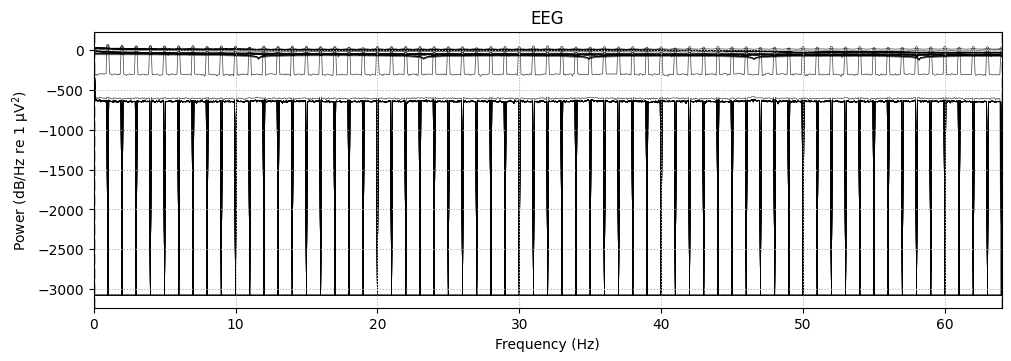

In [7]:
fig = raw.compute_psd().plot(amplitude=False)
# add some arrows at 60 Hz and its harmonics:
for ax in fig.axes[1:]:
    freqs = ax.lines[-1].get_xdata()
    psds = ax.lines[-1].get_ydata()
    for freq in (60, 120, 180, 240):
        idx = np.searchsorted(freqs, freq)
        ax.arrow(
            x=freqs[idx],
            y=psds[idx] + 18,
            dx=0,
            dy=-12,
            color="red",
            width=0.1,
            head_width=3,
            length_includes_head=True,
        )